# Notebook 3a: miDGD — TCGA + GTEx

## Section 1: Library, Functions, and Data Loading

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA


In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebook" else cwd
if not (repo_root / "models").is_dir():
    repo_root = next(
        p for p in (cwd, *cwd.parents)
        if (p / "models").is_dir() and (p / "notebook").is_dir()
    )
for p in (repo_root, repo_root / "notebook"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


In [3]:
%load_ext autoreload
%autoreload 2
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['mathtext.default'] = 'regular'


In [4]:
from base.dgd.nn import NB_Module, ZINB_Module
from base.dgd.DGD import DGD
from base.dgd.latent import RepresentationLayer
from base.utils.helpers import set_seed, get_activation
from base.model.decoder import Decoder
from base.data.combined import GeneExpressionDatasetCombined, StratifiedBatchSampler
from base.plotting.plot import plot_latent_space


In [5]:
from model_functions import load_trained_model, count_parameters, count_parameters_exclude_rep
from data_functions import generate_analysis_data, get_mirna_data as _get_mirna_data, _get_data_pred_from_rep
from plot_functions import (
    barplot_dataset, plot_latent_space_ms, plot_latent_space_dataonly,
    plot_average_correlation, plot_poisson_pseudo_r2_hist, plot_cancer_legend,
    plot_corr_vs_mean_expression_pub, plot_latent_space_multi_split, plot_latent_space_multi_grid,
)
from metrics_functions import calculate_ari, calculate_corr, poisson_pseudo_r2_vector
from clustering_functions import gmm_clustering, gmm_clustering_plot_diagonal, gmm_clustering_plot_diagonal_new

In [6]:
seed = 42
set_seed(seed)

num_workers = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 128
scaling_type = 'sum'
savedir = str(repo_root / 'plots/3a')
os.makedirs(savedir, exist_ok=True)


Device: cpu


In [7]:
df_mrna  = pd.read_table(repo_root / "data" / "TCGA_GTEx" / "miDGD" / "full" / "tcga_gtex_mrna.tsv",   sep="\t", index_col=0)
df_mirna = pd.read_table(repo_root / "data" / "TCGA_GTEx" / "miDGD" / "full" / "tcga_gtex_mirna.tsv",  sep="\t", index_col=0)

anno_train = pd.read_table(repo_root / "data" / "TCGA_GTEx" / "miDGD" / "TCGA_GTEx_train_anno.tsv", sep="\t", index_col=0)
anno_val   = pd.read_table(repo_root / "data" / "TCGA_GTEx" / "miDGD" / "TCGA_GTEx_val_anno.tsv",   sep="\t", index_col=0)
anno_test  = pd.read_table(repo_root / "data" / "TCGA_GTEx" / "miDGD" / "TCGA_GTEx_test_anno.tsv",  sep="\t", index_col=0)

df_anno = pd.concat([anno_train, anno_val, anno_test], axis=0)
print(df_mrna.shape, df_mirna.shape)
print(anno_train.shape, anno_val.shape, anno_test.shape)
print("Batches:", df_anno['batch'].value_counts().to_dict())


(25038, 18393) (25038, 755)
(18008, 6) (3515, 6) (3515, 6)
Batches: {'GTEx': 15398, 'TCGA': 9640}


In [8]:
train_idx = anno_train.index
val_idx   = anno_val.index
test_idx  = anno_test.index

train_mrna = df_mrna.loc[train_idx]
val_mrna   = df_mrna.loc[val_idx]
test_mrna  = df_mrna.loc[test_idx]
train_mirna = df_mirna.loc[train_idx]
val_mirna   = df_mirna.loc[val_idx]
test_mirna  = df_mirna.loc[test_idx]

train_dataset      = GeneExpressionDatasetCombined(train_mrna, train_mirna, anno_train, scaling_type=scaling_type)
validation_dataset = GeneExpressionDatasetCombined(val_mrna,   val_mirna,   anno_val,   scaling_type=scaling_type)
test_dataset       = GeneExpressionDatasetCombined(test_mrna,  test_mirna,  anno_test,  scaling_type=scaling_type)

train_loader      = torch.utils.data.DataLoader(train_dataset,      batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader       = torch.utils.data.DataLoader(test_dataset,       batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

data_loader = train_loader, validation_loader, test_loader

# cancer_type (str_labels) → color: used by latent-space plots
color_mapping = dict(zip(train_loader.dataset.str_labels, train_loader.dataset.color))
# primary_site → color: used by GMM clustering plot
primary_color_mapping = dict(zip(train_loader.dataset.primary_site, train_loader.dataset.color))


## Section 2: Model Loading

In [9]:
dgd = load_trained_model("3a-tcga-gtex.pth", device)
print(dgd)
print(f"Trainable parameters (excl. representations): {count_parameters_exclude_rep(dgd):,}")


DGD(
  (decoder): Decoder(
    (main): ModuleList(
      (0): Linear(in_features=25, out_features=100, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=100, out_features=100, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=100, out_features=100, bias=True)
      (5): LeakyReLU(negative_slope=0.01)
    )
    (out_module_mirna): ZINB_Module(
      (fc): Sequential(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=128, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=128, out_features=755, bias=True)
      )
    )
    (out_module_mrna): NB_Module(
      (fc): Sequential(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=512, bias=True)
        (3): LeakyReLU(negative

## Section 3: Reproduce Results

### Generate Predictions

In [10]:
from functools import partial

mirna_column = train_mirna.columns
get_mirna_data = partial(
    _get_mirna_data,
    mirna_column_name=mirna_column,
    label_attr="primary_site",
    include_batch=False,
)

X_train, y_train, X_val, y_val, X_test, y_test = generate_analysis_data(
    dgd, train_loader, validation_loader, test_loader,
    mirna_column_name=mirna_column,
)
X_test.index  = y_test.index  = anno_test.index
X_train.index = y_train.index = anno_train.index


### Data Distribution

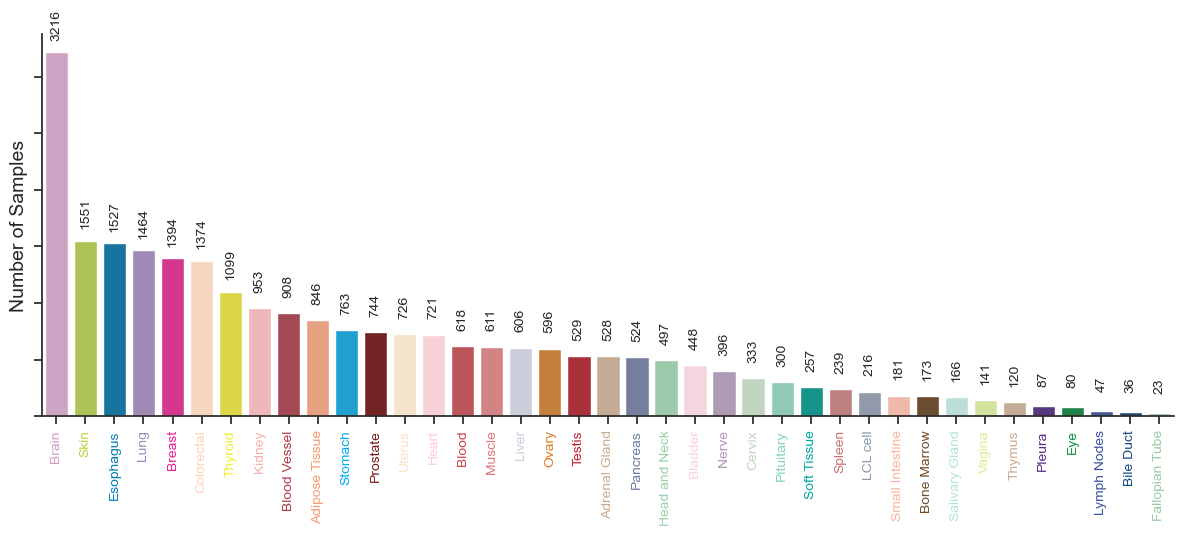

In [11]:
barplot_dataset(
    df_anno, groupby='primary_site', figsize=(12, 5.5),
    savedir=savedir, filename='TCGA+GTEx sample distribution.svg',
    xlabel='', ylabel='Number of Samples',
    xtick_fontsize=10, annotate_fontsize=10, save_format='svg',
)


### Latent Space PCA

Train ARI: 0.3563


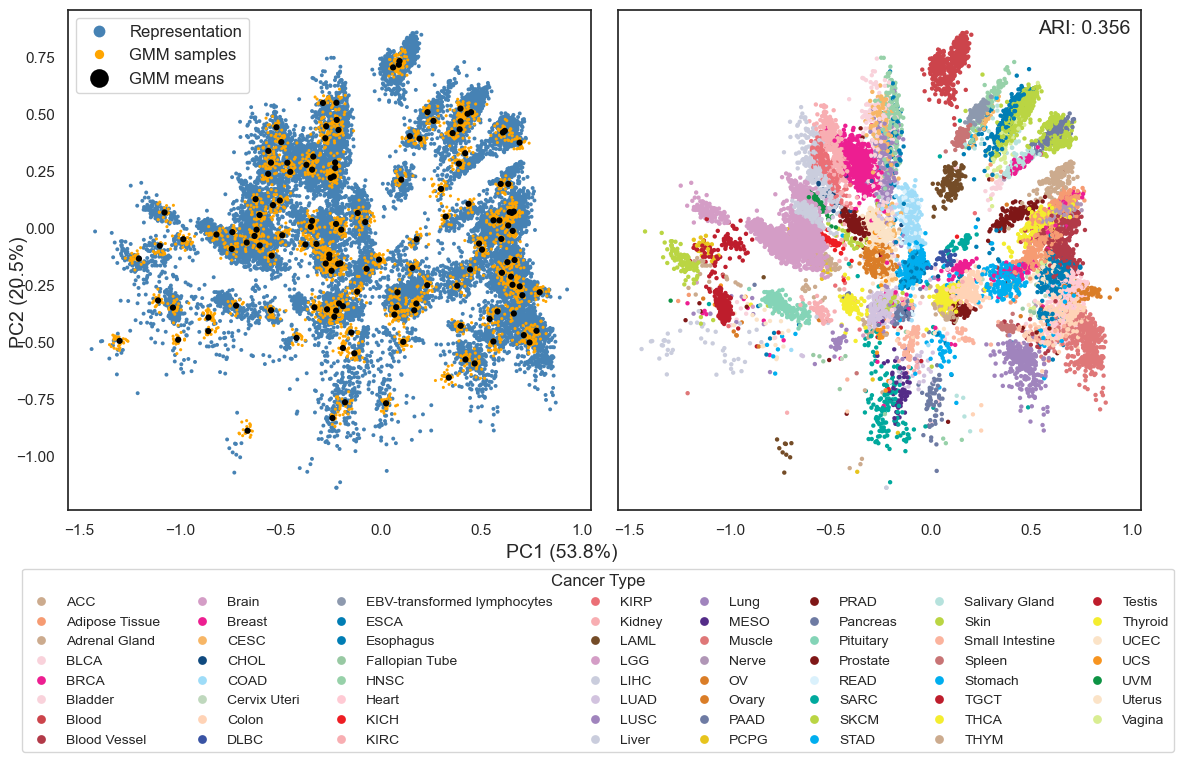

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [12]:
ari = calculate_ari(dgd, dgd.train_rep.z, data_loader, method='gmm', split='train')
print(f"Train ARI: {ari:.4f}")

plot_latent_space_ms(
    *dgd.get_latent_space_values("train", 3000),
    dgd.gmm, train_loader.dataset.str_labels,
    color_mapping, data_loader=train_loader,
    title="Train", savedir=savedir,
    filename="TCGA+GTEx training latent space.svg", ari=ari,
)


Test ARI: 0.3838


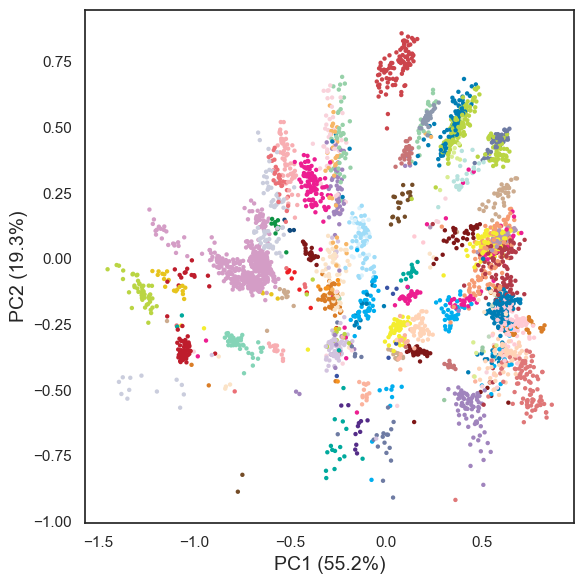

In [13]:
ari_test = calculate_ari(dgd, dgd.test_rep.z, data_loader, method='gmm', split='test')
print(f"Test ARI: {ari_test:.4f}")

plot_latent_space_dataonly(
    *dgd.get_latent_space_values("test", 2000),
    dgd.gmm, test_loader.dataset.str_labels,
    color_mapping, title="Test",
    savedir=savedir, filename="TCGA+GTEx test latent space.svg",
)


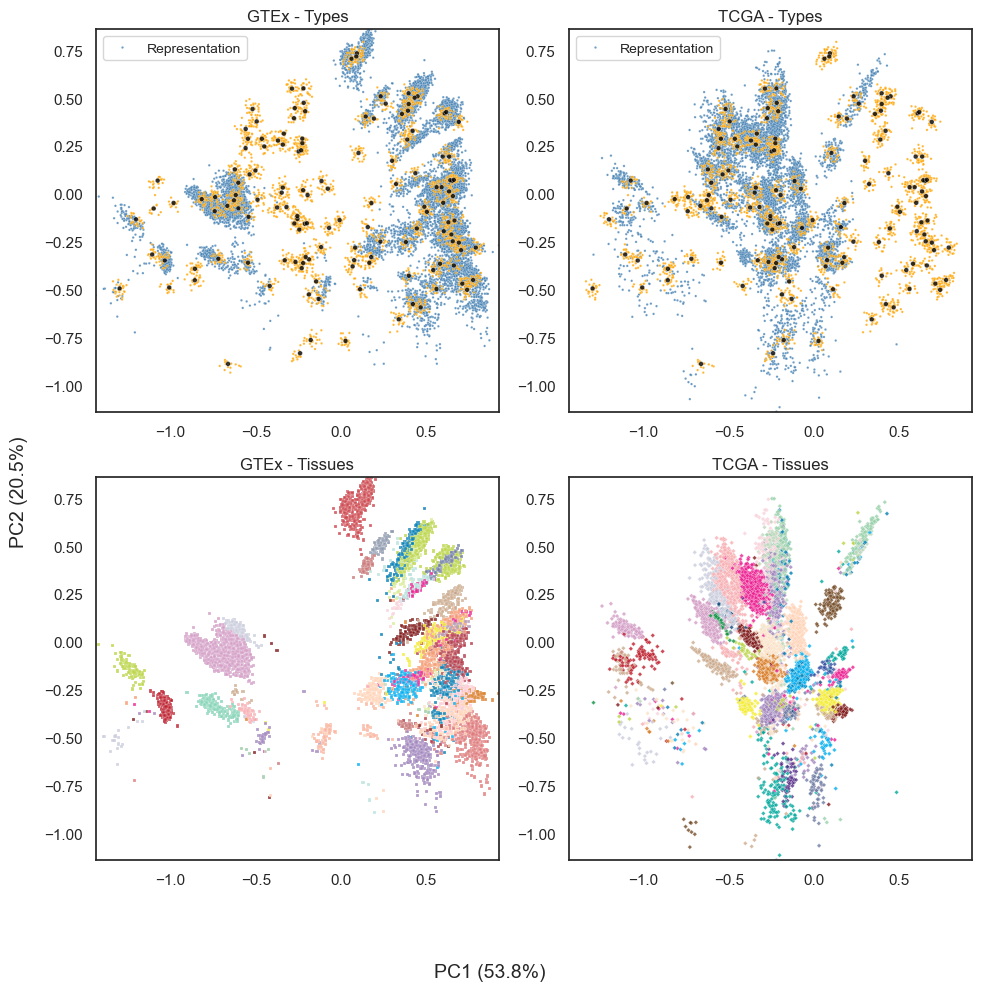

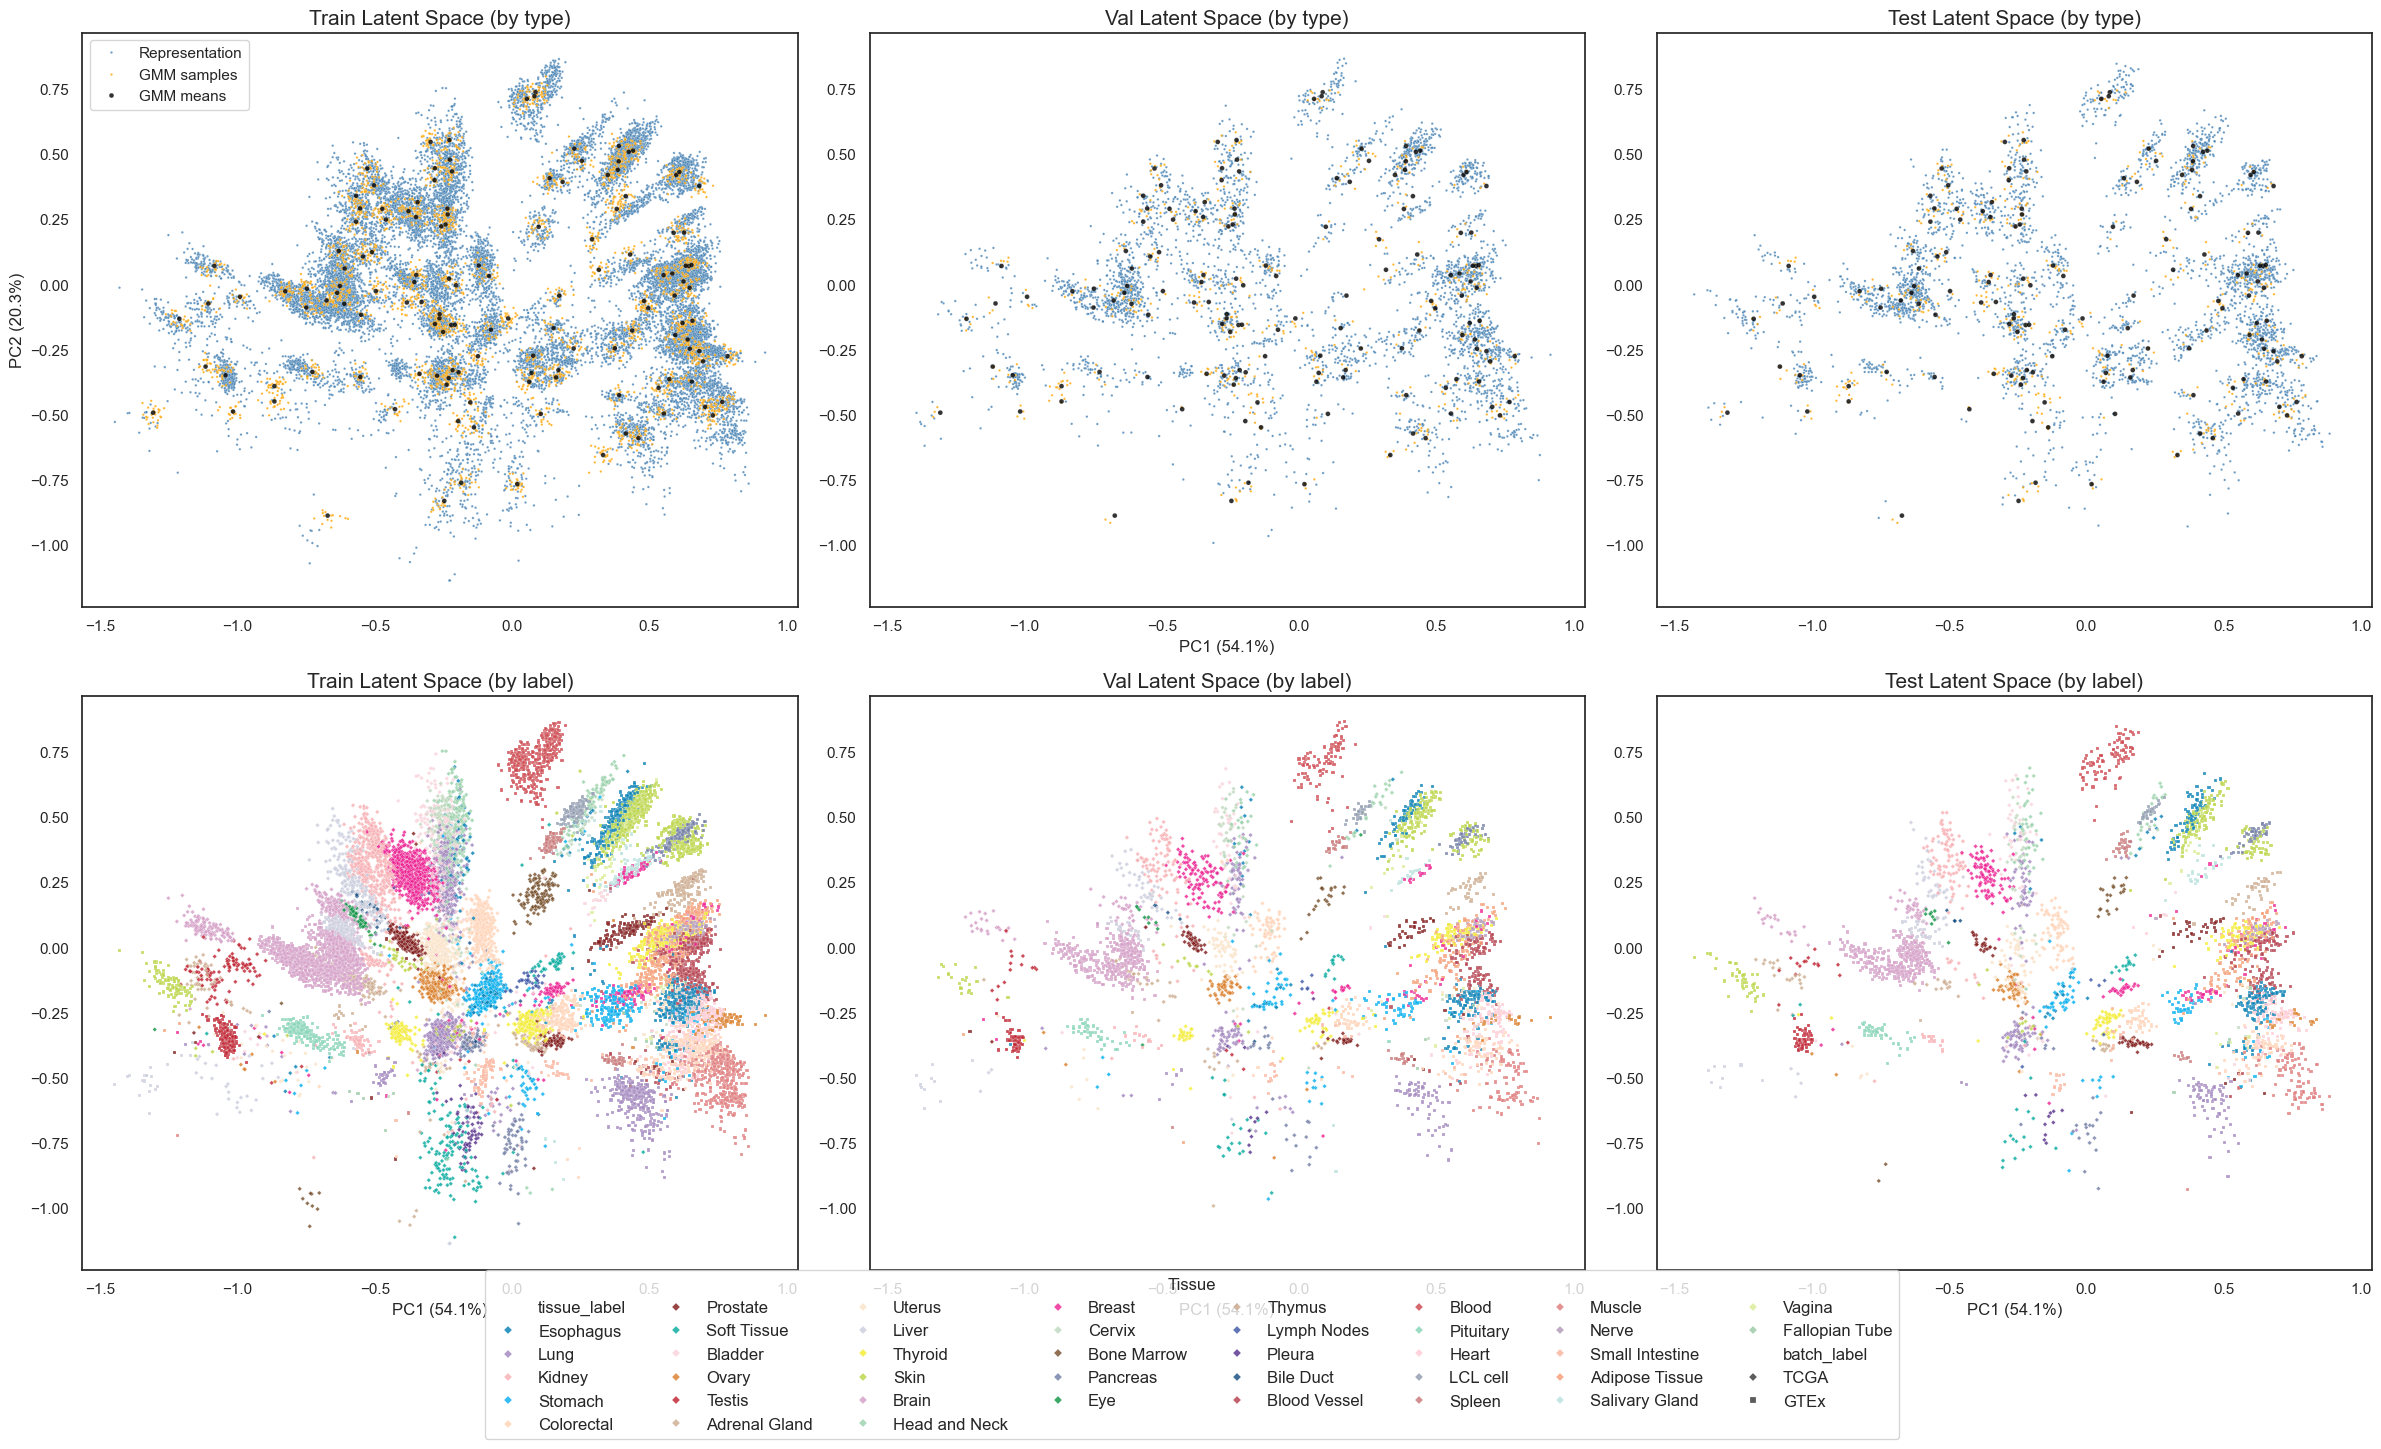

In [14]:
# Latent space split by batch (TCGA vs GTEx)
train_rep_z, gmm_means, gmm_samples = dgd.get_latent_space_values("train", 3000)
plot_latent_space_multi_split(
    train_rep_z, gmm_means, gmm_samples,
    tissue_labels=list(train_loader.dataset.primary_site),
    batch_labels=list(train_loader.dataset.batch),
    color_mapping=primary_color_mapping,
    savedir=savedir,
    filename="TCGA+GTEx training latent space by batch.svg",
)

# Latent space grid across train / val / test
val_rep_z  = dgd.val_rep.z.clone().detach().cpu().numpy()
test_rep_z = dgd.test_rep.z.clone().detach().cpu().numpy()
gmm_samples_sm = dgd.gmm.sample(500).detach().cpu().numpy()

plot_latent_space_multi_grid(
    (train_rep_z, gmm_means, gmm_samples),
    (val_rep_z,   gmm_means, gmm_samples_sm),
    (test_rep_z,  gmm_means, gmm_samples_sm),
    list(train_loader.dataset.primary_site),
    list(validation_loader.dataset.primary_site),
    list(test_loader.dataset.primary_site),
    list(train_loader.dataset.batch),
    list(validation_loader.dataset.batch),
    list(test_loader.dataset.batch),
    primary_color_mapping,
    savedir=savedir,
    filename="TCGA+GTEx latent space grid.svg",
)

### GMM Clustering

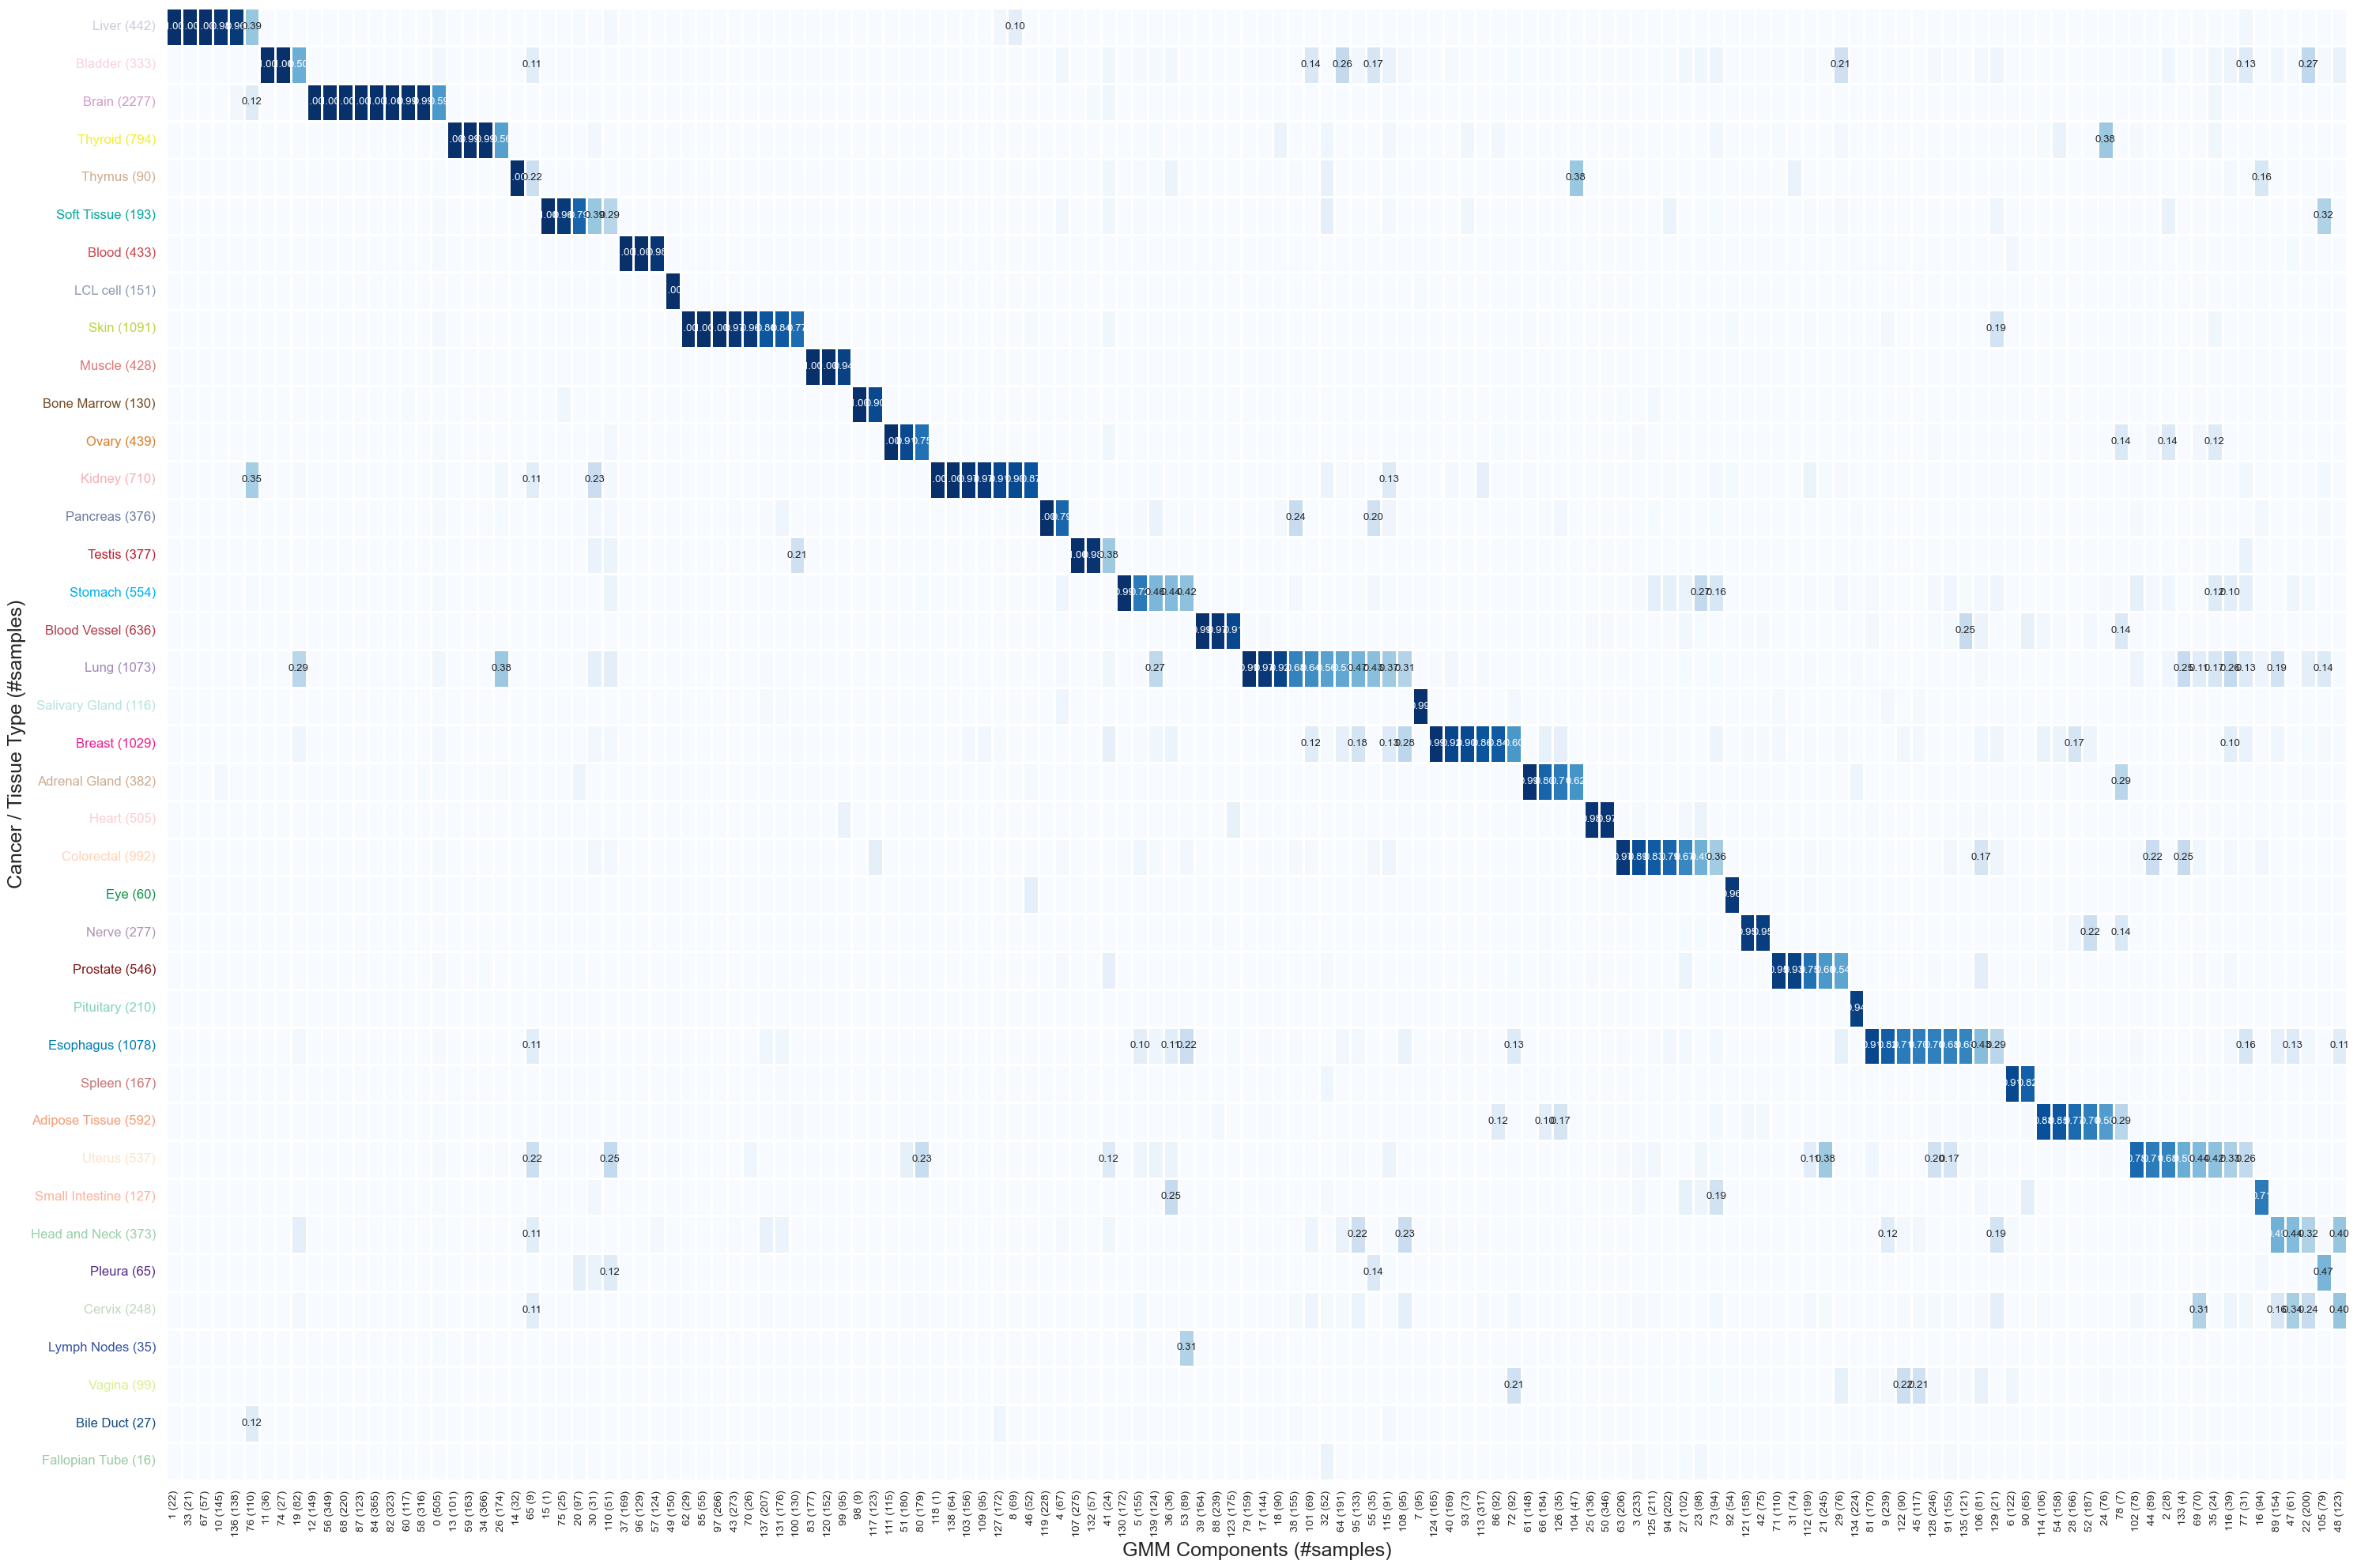

In [15]:
train_clustering = gmm_clustering(dgd, dgd.train_rep)
gmm_clustering_plot_diagonal_new(
    train_clustering, train_loader, primary_color_mapping,
    axis='comp', savedir=savedir, filename='TCGA+GTEx GMM component assignment.svg',
)

### Average Correlation

Mean Pearson: 0.6555  Mean Spearman: 0.6669


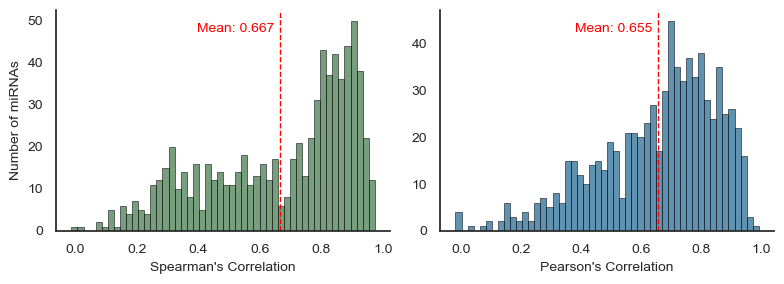

In [16]:
corr_data = calculate_corr(X_test, y_test, axis=0)
print(f"Mean Pearson: {corr_data['pearson'].mean():.4f}  Mean Spearman: {corr_data['spearman'].mean():.4f}")
plot_average_correlation(corr_data, savedir=savedir, filename='TCGA+GTEx test prediction correlation.svg')


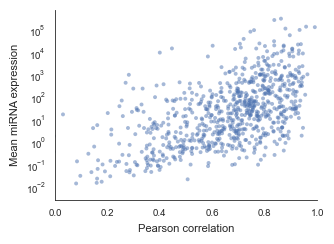

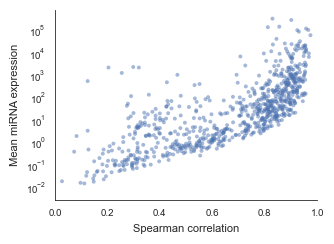

,pearson,spearman,r2,pearson_p,spearman_p,r2_p,mirna,mean_expression
0,0.990779,0.811606,0.981644,0.000000,0.000000e+00,0.000000,hsa-miR-9-5p,136794.218750
1,0.962570,0.914019,0.926540,0.000000,0.000000e+00,0.000000,hsa-miR-145-3p,1078.532837
2,0.957458,0.855196,0.916726,0.000000,0.000000e+00,0.000000,hsa-miR-148a-3p,144007.703125
3,0.954020,0.357954,0.910153,0.000000,9.483750e-107,0.000000,hsa-miR-506-3p,132.620178
4,0.946846,0.909326,0.896517,0.000000,0.000000e+00,0.000000,hsa-miR-487b-3p,842.768250
...,...,...,...,...,...,...,...,...
750,0.030779,0.354032,0.000947,0.068061,2.636598e-104,0.068060,hsa-miR-518c-5p,17.614346
751,-0.003780,0.082483,0.000014,0.822713,9.739652e-07,0.822713,hsa-miR-372-5p,1.907255
752,-0.004516,0.073304,0.000020,0.788981,1.359346e-05,0.788983,hsa-miR-302d-5p,0.382077
753,-0.012864,0.026996,0.000165,0.445810,1.095423e-01,0.445812,hsa-miR-892c-5p,0.018350


In [17]:
plot_corr_vs_mean_expression_pub(
    y_test, corr_data, corr_type="pearson",
    savedir=savedir,
    filename="TCGA+GTEx Pearson correlation vs mean expression.svg",
)
plot_corr_vs_mean_expression_pub(
    y_test, corr_data, corr_type="spearman",
    savedir=savedir,
    filename="TCGA+GTEx Spearman correlation vs mean expression.svg",
)

### Per-batch Correlation


GTEx  Pearson=0.7007  Spearman=0.6277


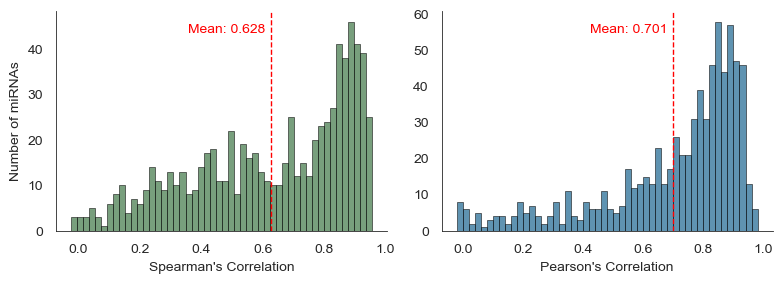


TCGA  Pearson=0.5016  Spearman=0.5312


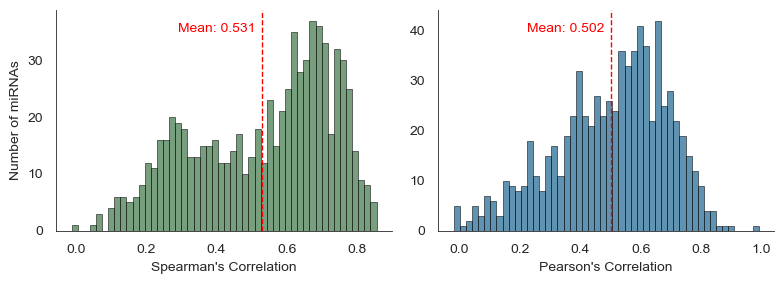

In [18]:
for batch_name in sorted(anno_test['batch'].unique()):
    idx = anno_test[anno_test['batch'] == batch_name].index
    c = calculate_corr(X_test.loc[idx], y_test.loc[idx], axis=0)
    print(f"\n{batch_name}  Pearson={c['pearson'].mean():.4f}  Spearman={c['spearman'].mean():.4f}")
    batch_fname = {
        'TCGA': 'TCGA test prediction correlation (TCGA+GTEx model).svg',
        'GTEx': 'GTEx test prediction correlation (TCGA+GTEx model).svg',
    }.get(batch_name, f'{batch_name} test prediction correlation.svg')
    plot_average_correlation(c, savedir=savedir, filename=batch_fname)


### Save Predictions

In [19]:
gtex_idx = anno_test[anno_test['batch'] == 'GTEx'].index
outdir_gtex = repo_root / "predictions" / "GTEx"
os.makedirs(outdir_gtex, exist_ok=True)
X_test.loc[gtex_idx].iloc[:, :-4].to_csv(outdir_gtex / "GTEx_pred_on_3a.tsv", sep="\t")
print("Saved GTEx predictions from model 3a.")


Saved GTEx predictions from model 3a.
